### Model Evaluation Workflow

The remainder of this notebook follows a consistent, repeated workflow for each model and market combination (e.g., LSTM on NASDAQ, RankLSTM on NYSE, etc.). This workflow consists of four main steps:

1.  **Setup**: Define the paths to the data and the specific hyperparameters used to train the pre-saved model.
2.  **Load Model**: Instantiate the appropriate model-handling class (e.g., `LSTM`, `RankLSTM`) and load the pre-trained model weights from the specified file.
3.  **Predict**: Use the loaded model to generate return predictions for the entire test period (starting from day `1008`).
4.  **Plot Results**: Pass the predictions, ground truth returns, and data mask to the `plot_top_k_return_ratios` function to visualize the backtesting performance.

Lastly, a summary of all the results is presented.

In [1]:
import matplotlib.pyplot as plt
import argparse
import copy
import numpy as np
import sys
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from time import time

sys.path.append(os.path.abspath('../../'))
from models.lstm import LSTMModel, LSTM
from models.rank_lstm import RankLSTMModel, RankLSTM
from models.rel_rank_lstm import ReRaLSTMModel, ReRaLSTM

## LSTM back-testing

### NASDAQ

In [2]:
data_path = '../../data/2013-01-01'
market_name = 'NASDAQ'
tickers_fname = f"{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv"
parameters = {'seq': 16, 'unit': 64, 'lr': 0.001, 'alpha': 0.1}

In [3]:
lstm_baseline = LSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    gpu=torch.cuda.is_available()
)
lstm_model = lstm_baseline.load_model(f'../../data/pretrain/pretrain/{market_name}_lstm_model.pt')

#tickers selected: 1026
Raw prices shape: (1026, 1245)
single EOD data shape: (1245, 6)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NASDAQ_lstm_model.pt


In [4]:
lstm_nasdaq_pred, lstm_nasdaq_gt, lstm_nasdaq_mask, lstm_nasdaq_perf = lstm_baseline.predict(lstm_model, start=1008)
print(lstm_nasdaq_pred.shape)    # (num_tickers, test_days)
print(lstm_nasdaq_gt.shape)    # (num_tickers, test_days)
print(lstm_nasdaq_mask.shape)          # (num_tickers, test_days)
lstm_nasdaq_perf

(1026, 237)
(1026, 237)
(1026, 237)


{'mse': np.float64(0.00037863636398905673),
 'mrrt': np.float64(0.006071876064861353),
 'btl': np.float64(0.8005663457151968),
 'btl5': np.float64(1.0685835086391298),
 'btl10': np.float64(1.1423986669295119)}

### NYSE

In [5]:
data_path = '../../data/2013-01-01'
market_name = 'NYSE'
tickers_fname = f"{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv"
parameters = {'seq': 8, 'unit': 32, 'lr': 0.001, 'alpha': 10}

In [6]:
lstm_model = lstm_baseline.load_model(f'../../data/pretrain/pretrain/{market_name}_lstm_model.pt')

Model loaded from ../../data/pretrain/pretrain/NYSE_lstm_model.pt


In [7]:
lstm_nyse_pred, lstm_nyse_gt, lstm_nyse_mask, lstm_nyse_perf = lstm_baseline.predict(lstm_model, start=1008)
print(lstm_nyse_pred.shape)    # (num_tickers, test_days)
print(lstm_nyse_gt.shape)    # (num_tickers, test_days)
print(lstm_nyse_mask.shape)          # (num_tickers, test_days)
lstm_nyse_perf

(1026, 237)
(1026, 237)
(1026, 237)


{'mse': np.float64(0.00037873913717238506),
 'mrrt': np.float64(0.009854114998590851),
 'btl': np.float64(1.2733875801422982),
 'btl5': np.float64(1.1188463459140616),
 'btl10': np.float64(0.9907055598501759)}

## RankLSTM back-testing

### NASDAQ backtesting

In [8]:
data_path = '../../data/2013-01-01'
market_name = 'NASDAQ'
tickers_fname = f"{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv"
parameters = {'seq': 16, 'unit': 64, 'lr': 0.001, 'alpha': 0.1}

In [9]:
rank_lstm = RankLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    gpu=torch.cuda.is_available()
)
rank_lstm_model = rank_lstm.load_model(f'../../data/pretrain/pretrain/{market_name}_ranklstm_model.pt')

#tickers selected: 1026
Raw prices shape: (1026, 1245)
single EOD data shape: (1245, 6)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NASDAQ_ranklstm_model.pt


In [10]:
rank_lstm_nasdaq_pred, rank_lstm_nasdaq_gt, rank_lstm_nasdaq_mask, rank_lstm_nasdaq_perf = rank_lstm.predict(rank_lstm_model, start=1008)
print(rank_lstm_nasdaq_pred.shape)    # (num_tickers, test_days)
print(rank_lstm_nasdaq_gt.shape)    # (num_tickers, test_days)
print(rank_lstm_nasdaq_mask.shape)          # (num_tickers, test_days)
rank_lstm_nasdaq_perf

(1026, 237)
(1026, 237)
(1026, 237)


{'mse': np.float64(0.3712599877710443),
 'mrrt': np.float64(0.021320617280677828),
 'btl': np.float64(1.5484323463606415),
 'btl5': np.float64(1.657204291175548),
 'btl10': np.float64(1.5025656683711526)}

### NYSE backtesting

In [11]:
data_path = '../../data/2013-01-01'
market_name = 'NYSE'
tickers_fname = f"{market_name}_tickers_qualify_dr-0.98_min-5_smooth.csv"
parameters = {'seq': 16, 'unit': 32, 'lr': 0.001, 'alpha': 10}

In [12]:
rank_lstm = RankLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    gpu=torch.cuda.is_available()
)
rank_lstm_model = rank_lstm.load_model(f'../../data/pretrain/pretrain/{market_name}_ranklstm_model.pt')

#tickers selected: 1737
Raw prices shape: (1737, 1245)
single EOD data shape: (1245, 6)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NYSE_ranklstm_model.pt


In [13]:
rank_lstm_nyse_pred, rank_lstm_nyse_gt, rank_lstm_nyse_mask, rank_lstm_nyse_perf = rank_lstm.predict(rank_lstm_model, start=1008)
print(rank_lstm_nyse_pred.shape)    # (num_tickers, test_days)
print(rank_lstm_nyse_gt.shape)    # (num_tickers, test_days)
print(rank_lstm_nyse_mask.shape)          # (num_tickers, test_days)
rank_lstm_nyse_perf

(1737, 237)
(1737, 237)
(1737, 237)


{'mse': np.float64(0.36727901822826836),
 'mrrt': np.float64(0.005959182182355945),
 'btl': np.float64(1.4248405360267498),
 'btl5': np.float64(1.1642507581260366),
 'btl10': np.float64(1.120002801997363)}

## ReRaLSTM back-testing

### NASDAQ-Industry

In [14]:
parameters = {'seq': 16, 'unit': 64, 'lr': 0.001, 'alpha': 0.1}
data_path='../../data/2013-01-01'
market_name='NASDAQ'
tickers_fname='NASDAQ_tickers_qualify_dr-0.98_min-5_smooth.csv'
relation_name='sector_industry'
emb_fname='NASDAQ_rank_lstm_seq-16_unit-64_2.csv.npy'

In [15]:
reralstm_nasdaq_industry = ReRaLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    relation_name=relation_name,
    emb_fname='NASDAQ_rank_lstm_seq-16_unit-64_2.csv.npy',
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    flat=False,
    gpu=True,
    in_pro=False
)
reralstm_nasdaq_industry_model = reralstm_nasdaq_industry.load_model(f'../../data/pretrain/pretrain/{market_name}_{relation_name}_reralstm_model.pt')

#tickers selected: 1026
Raw prices shape: (1026, 1245)
single EOD data shape: (1245, 6)
relation encoding shape: (1026, 1026, 97)
relation encoding shape: (1026, 1026, 97)
relation mask shape: (1026, 1026)
embedding shape: (1026, 1245, 64)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NASDAQ_sector_industry_reralstm_model.pt


In [16]:
reralstm_nasdaq_ind_pred, reralstm_nasdaq_ind_gt, reralstm_nasdaq_ind_mask, reralstm_nasdaq_ind_perf = reralstm_nasdaq_industry.predict(reralstm_nasdaq_industry_model, start=1008)
print(reralstm_nasdaq_ind_pred.shape)    # (num_tickers, test_days)
print(reralstm_nasdaq_ind_gt.shape)    # (num_tickers, test_days)
print(reralstm_nasdaq_ind_mask.shape)  # (num_tickers, test_days)
reralstm_nasdaq_ind_perf

(1026, 237)
(1026, 237)
(1026, 237)


{'mse': np.float64(0.00037734721517207085),
 'mrrt': np.float64(0.022731053879396376),
 'btl': np.float64(0.8567542355740443),
 'btl5': np.float64(1.255681764337351),
 'btl10': np.float64(1.204833611306095)}

### NASDAQ-wiki

In [17]:
parameters = {'seq': 16, 'unit': 64, 'lr': 0.001, 'alpha': 0.1}
data_path='../../data/2013-01-01'
market_name='NASDAQ'
tickers_fname='NASDAQ_tickers_qualify_dr-0.98_min-5_smooth.csv'
relation_name='wikidata'
emb_fname='NASDAQ_rank_lstm_seq-16_unit-64_2.csv.npy'

In [18]:
reralstm_nasdaq_wiki  = ReRaLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    relation_name=relation_name,
    emb_fname='NASDAQ_rank_lstm_seq-16_unit-64_2.csv.npy',
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    flat=False,
    gpu=True,
    in_pro=False
)
reralstm_nasdaq_wiki_model = reralstm_nasdaq_wiki.load_model(f'../../data/pretrain/pretrain/{market_name}_{relation_name}_reralstm_model.pt')

#tickers selected: 1026
Raw prices shape: (1026, 1245)
single EOD data shape: (1245, 6)
relation encoding shape: (1026, 1026, 43)
relation encoding shape: (1026, 1026, 43)
relation mask shape: (1026, 1026)
embedding shape: (1026, 1245, 64)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NASDAQ_wikidata_reralstm_model.pt


In [19]:
reralstm_nasdaq_wiki_pred, reralstm_nasdaq_wiki_gt, reralstm_nasdaq_wiki_mask, reralstm_nasdaq_wiki_perf = reralstm_nasdaq_wiki.predict(reralstm_nasdaq_wiki_model, start=1008)
print(reralstm_nasdaq_wiki_pred.shape)    # (num_tickers, test_days)
print(reralstm_nasdaq_wiki_gt.shape)    # (num_tickers, test_days)
print(reralstm_nasdaq_wiki_mask.shape)  # (num_tickers, test_days)
reralstm_nasdaq_wiki_perf

(1026, 237)
(1026, 237)
(1026, 237)


{'mse': np.float64(0.0003775667896117637),
 'mrrt': np.float64(0.03390798754378929),
 'btl': np.float64(2.218595513753826),
 'btl5': np.float64(1.3048797256837137),
 'btl10': np.float64(1.0932286095776358)}

### NYSE-Industry

In [20]:
parameters = {'seq': 8, 'unit': 32, 'lr': 0.001, 'alpha': 10}
data_path='../../data/2013-01-01'
market_name='NYSE'
tickers_fname='NYSE_tickers_qualify_dr-0.98_min-5_smooth.csv'
relation_name='sector_industry'
emb_fname='NYSE_rank_lstm_seq-8_unit-32_0.csv.npy'

In [21]:
reralstm_nyse_ind = ReRaLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    relation_name=relation_name,
    emb_fname=emb_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    flat=False,
    gpu=True,
    in_pro=False
)
reralstm_nyse_ind_model = reralstm_nyse_ind.load_model(f'../../data/pretrain/pretrain/{market_name}_{relation_name}_reralstm_model.pt')

#tickers selected: 1737
Raw prices shape: (1737, 1245)
single EOD data shape: (1245, 6)
relation encoding shape: (1737, 1737, 108)
relation encoding shape: (1737, 1737, 108)
relation mask shape: (1737, 1737)
embedding shape: (1737, 1245, 32)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NYSE_sector_industry_reralstm_model.pt


In [22]:
reralstm_nyse_ind_pred, reralstm_nyse_ind_gt, reralstm_nyse_ind_mask, reralstm_nyse_ind_perf = reralstm_nyse_ind.predict(reralstm_nyse_ind_model, start=1008)
print(reralstm_nyse_ind_pred.shape)    # (num_tickers, test_days)
print(reralstm_nyse_ind_gt.shape)    # (num_tickers, test_days)
print(reralstm_nyse_ind_mask.shape)  # (num_tickers, test_days)
reralstm_nyse_ind_perf

(1737, 237)
(1737, 237)
(1737, 237)


{'mse': np.float64(0.00022562968158225887),
 'mrrt': np.float64(0.019074480246918993),
 'btl': np.float64(0.18668869448447367),
 'btl5': np.float64(1.1105657828848055),
 'btl10': np.float64(1.033792789933614)}

### NYSE-Wiki

In [23]:
parameters = {'seq': 8, 'unit': 32, 'lr': 0.001, 'alpha': 10}
data_path='../../data/2013-01-01'
market_name='NYSE'
tickers_fname='NYSE_tickers_qualify_dr-0.98_min-5_smooth.csv'
relation_name='wikidata'
emb_fname='NYSE_rank_lstm_seq-8_unit-32_0.csv.npy'

In [24]:
reralstm_nyse_wiki = ReRaLSTM(
    data_path=data_path,
    market_name=market_name,
    tickers_fname=tickers_fname,
    relation_name=relation_name,
    emb_fname=emb_fname,
    parameters=parameters,
    steps=1,
    epochs=50,
    batch_size=None,
    flat=False,
    gpu=True,
    in_pro=False
)
reralstm_nyse_wiki_model = reralstm_nyse_wiki.load_model(f'../../data/pretrain/pretrain/{market_name}_{relation_name}_reralstm_model.pt')

#tickers selected: 1737
Raw prices shape: (1737, 1245)
single EOD data shape: (1245, 6)
relation encoding shape: (1737, 1737, 33)
relation encoding shape: (1737, 1737, 33)
relation mask shape: (1737, 1737)
embedding shape: (1737, 1245, 32)
device: cuda
Model loaded from ../../data/pretrain/pretrain/NYSE_wikidata_reralstm_model.pt


In [25]:
reralstm_nyse_wiki_pred, reralstm_nyse_wiki_gt, reralstm_nyse_wiki_mask, reralstm_nyse_wiki_perf = reralstm_nyse_wiki.predict(reralstm_nyse_wiki_model, start=1008)
print(reralstm_nyse_wiki_pred.shape)    # (num_tickers, test_days)
print(reralstm_nyse_wiki_gt.shape)    # (num_tickers, test_days)
print(reralstm_nyse_wiki_mask.shape)  # (num_tickers, test_days)
reralstm_nyse_wiki_perf

(1737, 237)
(1737, 237)
(1737, 237)


{'mse': np.float64(0.00022557162291100214),
 'mrrt': np.float64(0.03320037709410364),
 'btl': np.float64(1.618219104479067),
 'btl5': np.float64(1.34511656757968),
 'btl10': np.float64(1.2280972964261316)}

## Results

This final section provides a high-level summary and visual comparison of the different models and strategies evaluated in this project, based on the results from the paper and the backtesting runs. The primary metric for comparison is the **Investment Return Ratio (IRR)**, which represents the cumulative arithmetic return of a strategy over the test period.

### Model Architecture Comparison

The following plots compare the IRR of the three core model architectures (LSTM, Rank-LSTM, and ReRa-LSTM) for each market, separated by the type of relational data used. This helps to visualize the incremental benefit of adding the ranking loss (Rank-LSTM) and then the relational information (ReRa-LSTM).

#### 1. Performance with Sector-Industry Relations

This comparison shows how the models perform when using industry and sector co-membership as the relational signal.

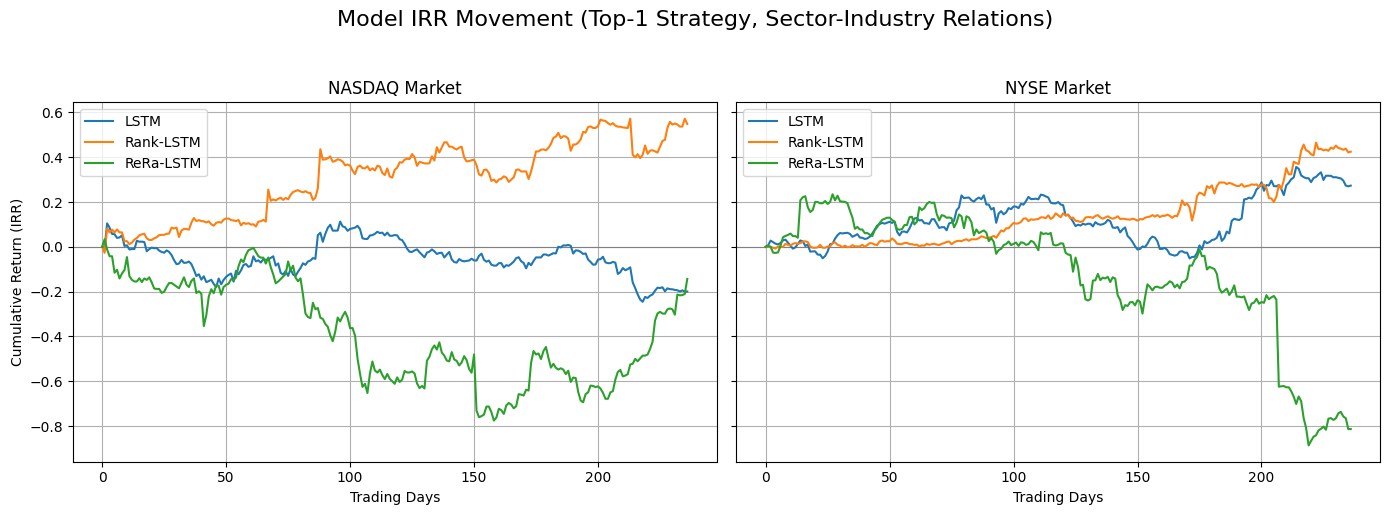

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def get_top_k_curve(pred, gt, mask, k=1):
    """Calculates and returns the cumulative return array for a single Top-K strategy."""
    num_days = pred.shape[1]
    cum_returns = [0.0]
    for day in range(num_days - 1):
        day_pred = pred[:, day]
        day_gt = gt[:, day + 1]
        day_mask = mask[:, day + 1]
        valid_indices = np.where(day_mask > 0.5)[0]
        if len(valid_indices) == 0:
            cum_returns.append(cum_returns[-1])
            continue
        ranked_indices = valid_indices[np.argsort(day_pred[valid_indices])[::-1]]
        top_k_indices = ranked_indices[:k]
        avg_return = np.mean(day_gt[top_k_indices])
        cum_returns.append(cum_returns[-1] + avg_return)
    return cum_returns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Model IRR Movement (Top-1 Strategy, Sector-Industry Relations)', fontsize=16, y=1.02)

# --- NASDAQ Plot (Industry Relations) ---
ax1 = axes[0]
ax1.set_title('NASDAQ Market')
ax1.set_ylabel('Cumulative Return (IRR)')
ax1.set_xlabel('Trading Days')
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.grid(True)

ax1.plot(get_top_k_curve(lstm_nasdaq_pred, lstm_nasdaq_gt, lstm_nasdaq_mask, k=1), label='LSTM')
ax1.plot(get_top_k_curve(rank_lstm_nasdaq_pred, rank_lstm_nasdaq_gt, rank_lstm_nasdaq_mask, k=1), label='Rank-LSTM')
ax1.plot(get_top_k_curve(reralstm_nasdaq_ind_pred, reralstm_nasdaq_ind_gt, reralstm_nasdaq_ind_mask, k=1), label='ReRa-LSTM')
ax1.legend()

# --- NYSE Plot (Industry Relations) ---
ax2 = axes[1]
ax2.set_title('NYSE Market')
ax2.set_xlabel('Trading Days')
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.grid(True)

ax2.plot(get_top_k_curve(lstm_nyse_pred, lstm_nyse_gt, lstm_nyse_mask, k=1), label='LSTM')
ax2.plot(get_top_k_curve(rank_lstm_nyse_pred, rank_lstm_nyse_gt, rank_lstm_nyse_mask, k=1), label='Rank-LSTM')
ax2.plot(get_top_k_curve(reralstm_nyse_ind_pred, reralstm_nyse_ind_gt, reralstm_nyse_ind_mask, k=1), label='ReRa-LSTM')
ax2.legend()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#### 2. Performance with Wikidata Relations

This plot shows the same model comparison, but this time using the more complex, graph-based relationships extracted from Wikidata.

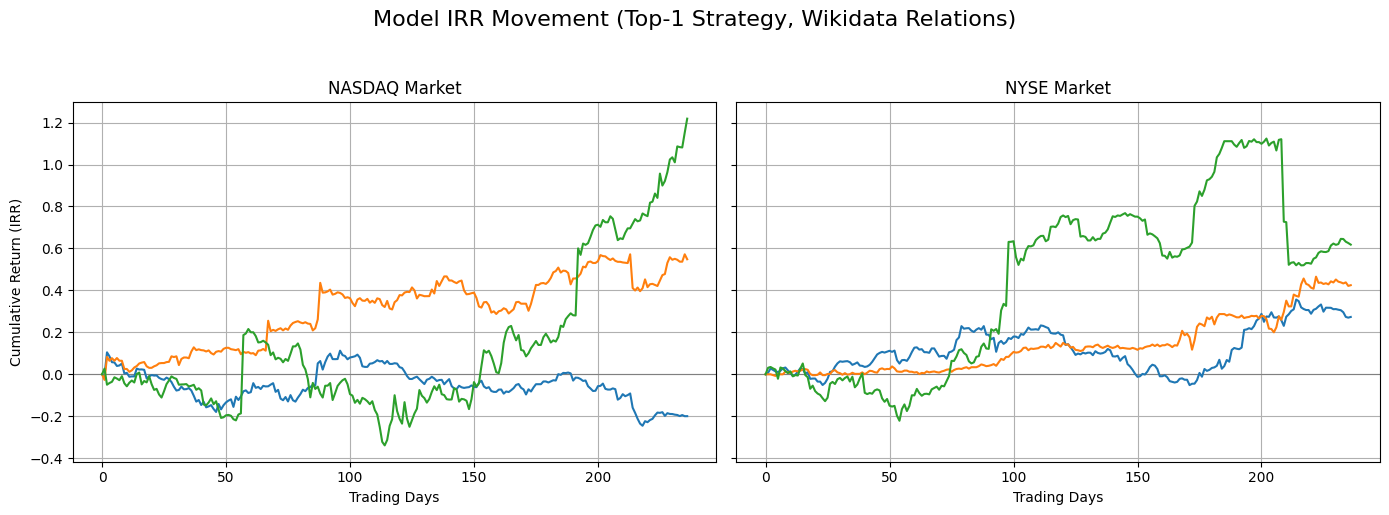

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Model IRR Movement (Top-1 Strategy, Wikidata Relations)', fontsize=16, y=1.02)

# --- NASDAQ Plot (Wikidata Relations) ---
ax1 = axes[0]
ax1.set_title('NASDAQ Market')
ax1.set_ylabel('Cumulative Return (IRR)')
ax1.set_xlabel('Trading Days')
ax1.axhline(0, color='grey', linewidth=0.8)
ax1.grid(True)

ax1.plot(get_top_k_curve(lstm_nasdaq_pred, lstm_nasdaq_gt, lstm_nasdaq_mask, k=1), label='LSTM')
ax1.plot(get_top_k_curve(rank_lstm_nasdaq_pred, rank_lstm_nasdaq_gt, rank_lstm_nasdaq_mask, k=1), label='Rank-LSTM')
ax1.plot(get_top_k_curve(reralstm_nasdaq_wiki_pred, reralstm_nasdaq_wiki_gt, reralstm_nasdaq_wiki_mask, k=1), label='ReRa-LSTM')

# --- NYSE Plot (Wikidata Relations) ---
ax2 = axes[1]
ax2.set_title('NYSE Market')
ax2.set_xlabel('Trading Days')
ax2.axhline(0, color='grey', linewidth=0.8)
ax2.grid(True)

ax2.plot(get_top_k_curve(lstm_nyse_pred, lstm_nyse_gt, lstm_nyse_mask, k=1), label='LSTM')
ax2.plot(get_top_k_curve(rank_lstm_nyse_pred, rank_lstm_nyse_gt, rank_lstm_nyse_mask, k=1), label='Rank-LSTM')
ax2.plot(get_top_k_curve(reralstm_nyse_wiki_pred, reralstm_nyse_wiki_gt, reralstm_nyse_wiki_mask, k=1), label='ReRa-LSTM')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [34]:
import pandas as pd

data_for_df = {
    ('NASDAQ', 'MSE'): [lstm_nasdaq_perf['mse'], rank_lstm_nasdaq_perf['mse'], reralstm_nasdaq_wiki_perf['mse']],
    ('NASDAQ', 'MRR'): [lstm_nasdaq_perf['mrrt'], rank_lstm_nasdaq_perf['mrrt'], reralstm_nasdaq_wiki_perf['mrrt']],
    ('NASDAQ', 'IRR'): [lstm_nasdaq_perf['btl'], rank_lstm_nasdaq_perf['btl'], reralstm_nasdaq_wiki_perf['btl']],
    ('NYSE', 'MSE'):   [lstm_nyse_perf['mse'], rank_lstm_nyse_perf['mse'], reralstm_nyse_wiki_perf['mse']],
    ('NYSE', 'MRR'):   [lstm_nyse_perf['mrrt'], rank_lstm_nyse_perf['mrrt'], reralstm_nyse_wiki_perf['mrrt']],
    ('NYSE', 'IRR'):   [lstm_nyse_perf['btl'], rank_lstm_nyse_perf['btl'], reralstm_nyse_wiki_perf['btl']]
}

index_labels = ['LSTM', 'Rank-LSTM', 'ReRa-LSTM']
final_df = pd.DataFrame(data_for_df, index=index_labels)

final_df.index.name = None
final_df.columns.names = [None, None]

formatters = {}
for market, metric in final_df.columns:
    if pd.api.types.is_numeric_dtype(final_df[(market, metric)]):
        if metric == 'IRR':
            formatters[(market, metric)] = '{:.2f}'.format
        elif metric == 'MSE':
             formatters[(market, metric)] = '{:.4f}'.format
        else:  # For MRR
            formatters[(market, metric)] = '{:.2e}'.format

display(final_df.style.format(formatters, na_rep="N/A").set_table_styles(
    [{'selector': 'th.col_heading', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
     {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).set_caption("Model Performance Comparison"))

### Back-testing Strategy Comparison
This table evaluates the **ReRa-LSTM** model's performance under different back-testing strategies (Top-1, Top-5, and Top-10) for both NASDAQ and NYSE markets. The performance is also compared against the theoretical maximum return ("Market") and two major market indices.

In [29]:
import yfinance as yf
import pandas as pd

def calculate_index_irr(ticker, start_date, end_date):
    """
    Downloads historical data for a given ticker and calculates the
    Investment Return Ratio (IRR) as the arithmetic sum of daily returns.
    """
    data = yf.download(ticker, start=pd.to_datetime(start_date) - pd.DateOffset(days=1), end=end_date)
    
    if data.empty:
        print(f"No data found for ticker {ticker} in the specified date range.")
        return 0.0
    
    # Calculate daily percentage change
    data['Daily Return'] = data['Close'].pct_change()
    
    # Filter to the exact test period
    test_period_data = data[start_date:end_date]
    
    # Calculate IRR as the sum of daily returns
    irr = test_period_data['Daily Return'].sum()
    
    print(f"Calculated IRR for {ticker} from {start_date} to {end_date}: {irr:.4f}")
    return irr

# Test period
start_date = '2017-01-03'
end_date = '2017-12-08'

# Calculate the IRR for S&P 500 and DJI
sp500_irr = calculate_index_irr('^GSPC', start_date, end_date)
dji_irr = calculate_index_irr('^DJI', start_date, end_date)

/tmp/ipykernel_21495/630312522.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=pd.to_datetime(start_date) - pd.DateOffset(days=1), end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_21495/630312522.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=pd.to_datetime(start_date) - pd.DateOffset(days=1), end=end_date)
[*********************100%***********************]  1 of 1 completed

Calculated IRR for ^GSPC from 2017-01-03 to 2017-12-08: 0.1574
Calculated IRR for ^DJI from 2017-01-03 to 2017-12-08: 0.1992


In [30]:
import pandas as pd

# Helper function to calculate the ideal market performance
def calculate_ideal_performance(ground_truth, mask):
    irr_top1, irr_top5, irr_top10 = 1.0, 1.0, 1.0
    num_days = ground_truth.shape[1]

    for i in range(num_days):
        day_gt = ground_truth[:, i]
        day_mask = mask[:, i]
        
        valid_indices = np.where(day_mask > 0.5)[0]
        if len(valid_indices) == 0:
            continue
            
        valid_gt = day_gt[valid_indices]
        ranked_indices = np.argsort(valid_gt)[::-1] # Best performers first
        
        irr_top1 += np.mean(valid_gt[ranked_indices[:1]])
        irr_top5 += np.mean(valid_gt[ranked_indices[:5]])
        irr_top10 += np.mean(valid_gt[ranked_indices[:10]])
        
    return {'btl': irr_top1, 'btl5': irr_top5, 'btl10': irr_top10}

# Ideal "Market" performance for NASDAQ for the test period
nasdaq_market_perf = calculate_ideal_performance(reralstm_nasdaq_wiki_gt, reralstm_nasdaq_wiki_mask)
print("Ideal NASDAQ Market Performance (Test Period):", nasdaq_market_perf)

# Ideal "Market" performance for NYSE for the test period
nyse_market_perf = calculate_ideal_performance(reralstm_nyse_wiki_gt, reralstm_nyse_wiki_mask)
print("Ideal NYSE Market Performance (Test Period):", nyse_market_perf)

# The evaluate function returns 1.0 + IRR. We subtract 1 to get the pure IRR.
table_data = {
    ('NASDAQ', 'Top-1'): [nasdaq_market_perf['btl'] - 1, reralstm_nasdaq_wiki_perf['btl'] - 1],
    ('NASDAQ', 'Top-5'): [nasdaq_market_perf['btl5'] - 1, reralstm_nasdaq_wiki_perf['btl5'] - 1],
    ('NASDAQ', 'Top-10'): [nasdaq_market_perf['btl10'] - 1, reralstm_nasdaq_wiki_perf['btl10'] - 1],
    ('NYSE', 'Top-1'): [nyse_market_perf['btl'] - 1, reralstm_nyse_wiki_perf['btl'] - 1],
    ('NYSE', 'Top-5'): [nyse_market_perf['btl5'] - 1, reralstm_nyse_wiki_perf['btl5'] - 1],
    ('NYSE', 'Top-10'): [nyse_market_perf['btl10'] - 1, reralstm_nyse_wiki_perf['btl10'] - 1],
}

index_labels = ['Market', 'ReRa-LSTM']
final_df = pd.DataFrame(table_data, index=index_labels)

final_df.loc['S&P 500'] = sp500_irr
final_df.loc['DJI'] = dji_irr

final_df.index.name = None
final_df.columns.names = [None, None]

display(final_df.style.format('{:.2f}', na_rep="N/A").set_table_styles(
    [{'selector': 'th.col_heading', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
     {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).set_caption("ReRa-LSTM Back-testing Strategy Performance (IRR)"))

Ideal NASDAQ Market Performance (Test Period): {'btl': np.float64(41.89135040342808), 'btl5': np.float64(25.52859560474754), 'btl10': np.float64(20.049296626448633)}
Ideal NYSE Market Performance (Test Period): {'btl': np.float64(36.35155626386404), 'btl5': np.float64(22.743157846108062), 'btl10': np.float64(18.119108785875138)}


In [31]:
def plot_top_k_return_ratios(pred, gt, mask, top_ks, ax, title):
    """
    Calculates and plots the cumulative return for Top-K strategies on a given axis.
    """
    num_days = pred.shape[1]
    cum_returns = {k: [0.0] for k in top_ks}

    for day in range(num_days - 1): 
        day_pred = pred[:, day]
        day_gt = gt[:, day + 1]       # next-day return
        day_mask = mask[:, day + 1]

        valid_indices = np.where(day_mask > 0.5)[0]
        if len(valid_indices) == 0:
            for k in top_ks:
                cum_returns[k].append(cum_returns[k][-1])
            continue

        ranked_indices = valid_indices[np.argsort(day_pred[valid_indices])[::-1]]

        for k in top_ks:
            top_k_indices = ranked_indices[:k]
            avg_return = np.mean(day_gt[top_k_indices])
            new_value = cum_returns[k][-1] + avg_return
            cum_returns[k].append(new_value)
    
    for k in top_ks:
        ax.plot(cum_returns[k], label=f'Top-{k}')
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('Cumulative Return (IRR)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

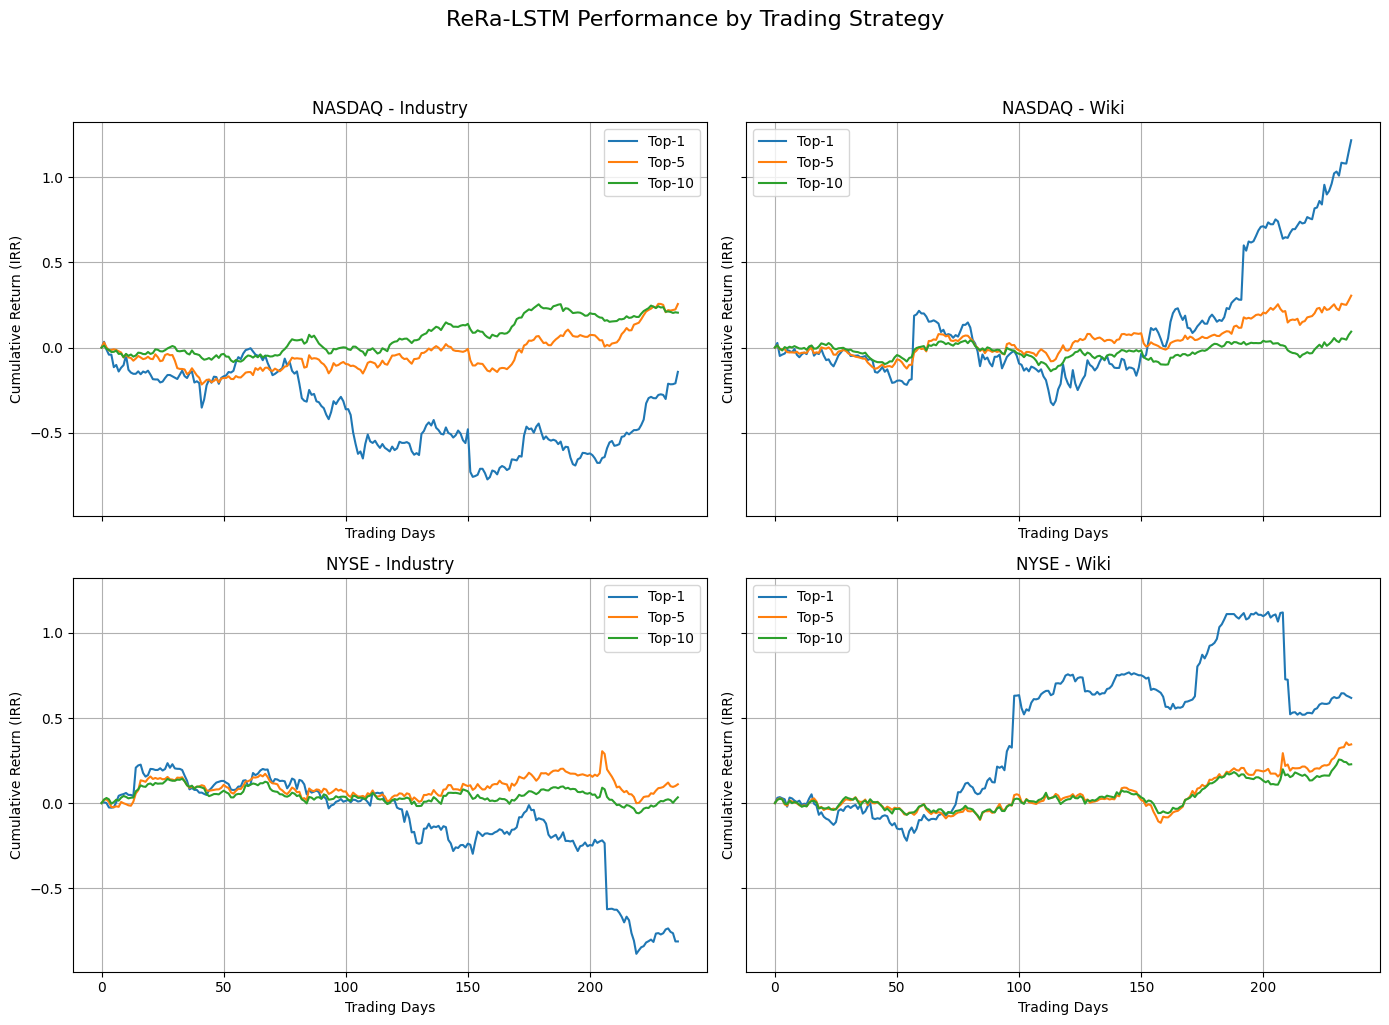

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle('ReRa-LSTM Performance by Trading Strategy', fontsize=16, y=1.02)
top_k_values = [1, 5, 10]

# --- 1. NASDAQ-Industry ---
plot_top_k_return_ratios(reralstm_nasdaq_ind_pred, reralstm_nasdaq_ind_gt, reralstm_nasdaq_ind_mask,
                             top_k_values, ax=axes[0, 0], title='NASDAQ - Industry')

# --- 2. NASDAQ-Wiki ---
plot_top_k_return_ratios(reralstm_nasdaq_wiki_pred, reralstm_nasdaq_wiki_gt, reralstm_nasdaq_wiki_mask,
                         top_k_values, ax=axes[0, 1], title='NASDAQ - Wiki')

# --- 3. NYSE-Industry ---
plot_top_k_return_ratios(reralstm_nyse_ind_pred, reralstm_nyse_ind_gt, reralstm_nyse_ind_mask,
                         top_k_values, ax=axes[1, 0], title='NYSE - Industry')

# --- 4. NYSE-Wiki ---
plot_top_k_return_ratios(reralstm_nyse_wiki_pred, reralstm_nyse_wiki_gt, reralstm_nyse_wiki_mask,
                         top_k_values, ax=axes[1, 1], title='NYSE - Wiki')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()